# datasetInsight: menggali insight dari `dataset/master.csv`

Notebook ini **hanya membaca** `dataset/master.csv` (hasil `processing_RawToDataset`) dan menghitung insight dalam 7 kelompok:

1. Gambaran umum
2. Tren bulanan
3. Kategori (frekuensi vs nominal)
4. Item
5. Pola waktu
6. Pola perilaku
7. Anomali & pengeluaran tak rutin

Ditambah pengecekan kualitas data dan ringkasan otomatis di akhir.
Setiap bagian berdiri sendiri, jadi bagian yang tidak berguna bisa dilewati atau dihapus.

## 0. Konfigurasi & load data

In [1]:
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE_DIR = Path.cwd()
MASTER_PATH = BASE_DIR / "dataset" / "master.csv"
OUTPUT_DIR = BASE_DIR / "insight_output"

SAVE_OUTPUT = False            # True -> tabel hasil disimpan sebagai CSV di insight_output/
TOP_N = 10                     # jumlah baris pada peringkat
OUTLIER_MIN_COUNT = 10         # kategori dengan transaksi < ini tidak dicek outlier
BIG_TICKET_QUANTILE = 0.98     # transaksi >= kuantil ini dianggap "besar / tak rutin"
SMALL_AMOUNT = 1000            # nominal < ini dicurigai lupa menulis 'k'
FLAG_CATEGORIES = {"Uncategorized", "Lain-lain"}

DAY_NAMES = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100

results = {}   # tabel hasil, dipakai untuk penyimpanan opsional di bagian akhir


def rp(x):
    return "Rp" + f"{x:,.0f}".replace(",", ".")


rp_axis = FuncFormatter(lambda x, _: f"{x/1000:,.0f}k".replace(",", "."))

df = pd.read_csv(MASTER_PATH, parse_dates=["date"])
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# exp = hanya baris yang benar-benar ada pengeluaran (item tidak kosong)
exp = df.dropna(subset=["item"]).copy()
exp["amount"] = exp["amount"].astype(float)
exp["ym"] = exp["date"].dt.to_period("M")

# daily = satu baris per tanggal (hari tanpa pengeluaran tetap ada dengan total 0)
daily = df.groupby("date")["amount"].sum().rename("total").to_frame()
daily["n_transaksi"] = exp.groupby("date").size().reindex(daily.index).fillna(0).astype(int)
daily["weekday"] = daily.index.dayofweek
daily["hari"] = daily["weekday"].map(dict(enumerate(DAY_NAMES)))

print(f"{len(df)} baris | {len(exp)} transaksi | {len(daily)} hari tercatat "
      f"({daily.index.min().date()} s.d. {daily.index.max().date()})")

1297 baris | 1220 transaksi | 456 hari tercatat (2025-07-01 s.d. 2026-09-29)


## 1. Gambaran umum

In [2]:
n_days = len(daily)
zero_days = int((daily["total"] == 0).sum())

overview = pd.Series({
    "Total pengeluaran": rp(exp["amount"].sum()),
    "Jumlah transaksi": len(exp),
    "Hari tercatat": n_days,
    "Hari tanpa pengeluaran": f"{zero_days} ({zero_days / n_days:.1%})",
    "Rata-rata per hari": rp(daily["total"].mean()),
    "Median per hari": rp(daily["total"].median()),
    "Rata-rata per transaksi": rp(exp["amount"].mean()),
    "Median per transaksi": rp(exp["amount"].median()),
    "Transaksi per hari (rata-rata)": round(daily["n_transaksi"].mean(), 1),
}, name="nilai")
display(overview.to_frame())

# rata-rata jauh di atas median = ada hari-hari besar yang menarik angka ke atas
print(f"Rasio rata-rata/median harian: {daily['total'].mean() / max(daily['total'].median(), 1):.2f}")

,nilai
Total pengeluaran,Rp25.600.464
Jumlah transaksi,1220
Hari tercatat,456
Hari tanpa pengeluaran,77 (16.9%)
Rata-rata per hari,Rp56.141
Median per hari,Rp34.000
Rata-rata per transaksi,Rp20.984
Median per transaksi,Rp12.000
Transaksi per hari (rata-rata),2.7


Rasio rata-rata/median harian: 1.65


## 2. Tren bulanan

,total,transaksi,hari_tercatat,hari_hemat,rata2_per_hari,lengkap,perubahan_%
date,,,,,,,
2025-07,2149500.0,118,31,0,69339.0,True,NaN
2025-08,1534000.0,72,31,7,49484.0,True,-28.6
2025-09,1668500.0,102,30,1,55617.0,True,8.8
2025-10,1927000.0,118,31,1,62161.0,True,15.5
2025-11,1484000.0,81,30,1,49467.0,True,-23.0
2025-12,1988000.0,99,31,2,64129.0,True,34.0
2026-01,2004000.0,105,31,1,64645.0,True,0.8
2026-02,1116000.0,66,28,6,39857.0,True,-44.3
2026-03,1907000.0,41,31,10,61516.0,True,70.9


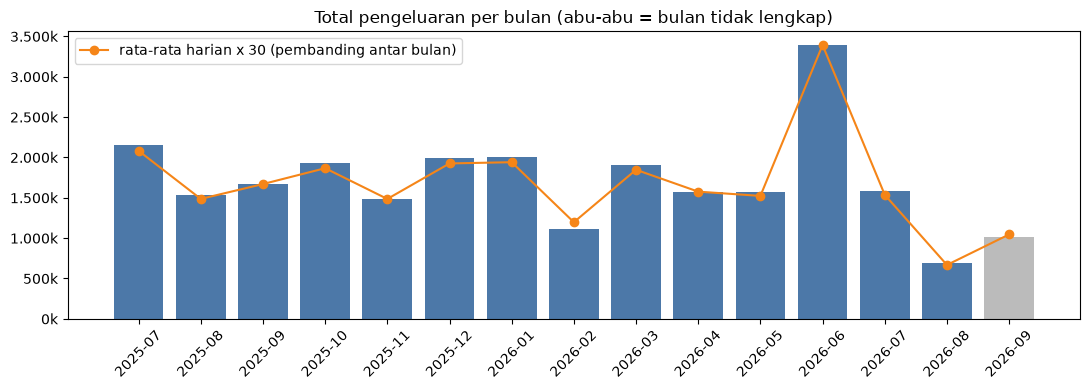

In [3]:
monthly = daily.groupby(daily.index.to_period("M")).agg(
    total=("total", "sum"),
    transaksi=("n_transaksi", "sum"),
    hari_tercatat=("total", "size"),
    hari_hemat=("total", lambda s: int((s == 0).sum())),
)
monthly["rata2_per_hari"] = (monthly["total"] / monthly["hari_tercatat"]).round(0)
monthly["lengkap"] = monthly["hari_tercatat"] >= monthly.index.days_in_month
monthly["perubahan_%"] = (monthly["total"].pct_change() * 100).round(1)
display(monthly)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#4C78A8" if ok else "#BBBBBB" for ok in monthly["lengkap"]]
ax.bar(monthly.index.astype(str), monthly["total"], color=colors)
ax.plot(monthly.index.astype(str), monthly["rata2_per_hari"] * 30, color="#F58518", marker="o",
        label="rata-rata harian x 30 (pembanding antar bulan)")
ax.yaxis.set_major_formatter(rp_axis)
ax.set_title("Total pengeluaran per bulan (abu-abu = bulan tidak lengkap)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout(); plt.show()

results["bulanan"] = monthly

## 3. Kategori: frekuensi vs nominal

,frekuensi,total,rata2,median,porsi_frekuensi_%,porsi_nominal_%,rank_frekuensi,rank_nominal
category,,,,,,,,
Makanan & Minuman,698,9456900.0,13549.0,11000.0,57.0,37.0,1,1
Uncategorized,145,8040064.0,55449.0,15000.0,12.0,31.0,2,2
Transportasi,128,2457000.0,19195.0,24000.0,10.0,10.0,3,3
Kebutuhan Rumah,77,1942500.0,25227.0,14000.0,6.0,8.0,5,4
Jajan,98,1362000.0,13898.0,10000.0,8.0,5.0,4,5
Olahraga,30,1099000.0,36633.0,15000.0,2.0,4.0,6,6
Kebutuhan Diri,20,495000.0,24750.0,20500.0,2.0,2.0,7,7
Elektronik & Hobi,14,383500.0,27393.0,18000.0,1.0,2.0,8,8
Lain-lain,10,364500.0,36450.0,30750.0,1.0,1.0,9,9


Sering tapi kecil (rank frekuensi jauh lebih baik dari rank nominal): -
Jarang tapi besar (rank nominal jauh lebih baik dari rank frekuensi): -


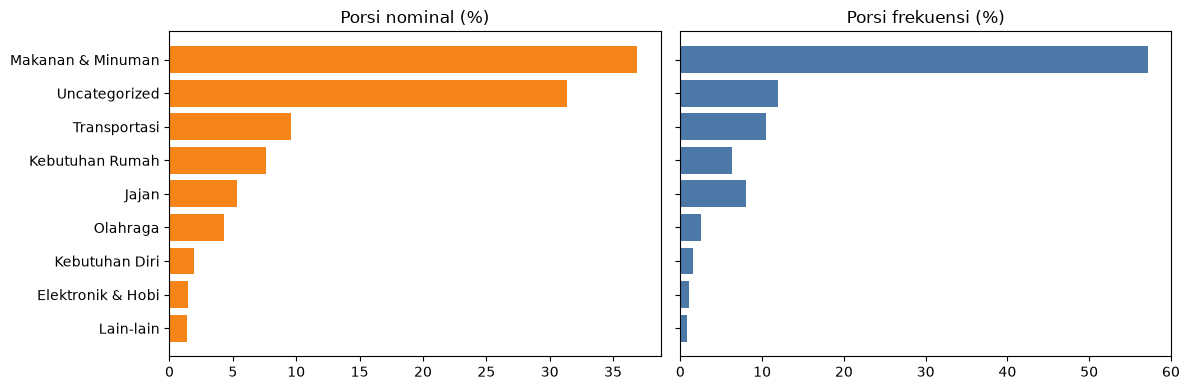

category,Elektronik & Hobi,Jajan,Kebutuhan Diri,Kebutuhan Rumah,Lain-lain,Makanan & Minuman,Olahraga,Transportasi,Uncategorized
ym,,,,,,,,,
2025-07,0.0,5.9,1.3,1.2,9.7,40.8,0.0,14.7,26.4
2025-08,11.2,5.3,1.0,3.9,2.3,26.4,6.2,10.2,33.5
2025-09,0.0,2.1,1.2,2.7,0.0,44.6,6.0,10.2,33.2
2025-10,3.0,1.9,3.9,23.6,0.0,41.7,4.2,6.6,15.1
2025-11,0.0,4.7,0.0,21.2,0.0,52.0,2.2,6.4,13.5
2025-12,2.5,10.0,1.3,5.3,0.0,52.7,3.0,10.4,14.8
2026-01,0.0,5.8,0.3,7.4,0.0,50.9,3.7,9.6,22.3
2026-02,0.0,1.5,4.3,8.6,0.0,47.8,10.3,11.4,16.2
2026-03,0.3,7.2,0.0,5.6,0.0,17.5,5.5,5.6,58.4


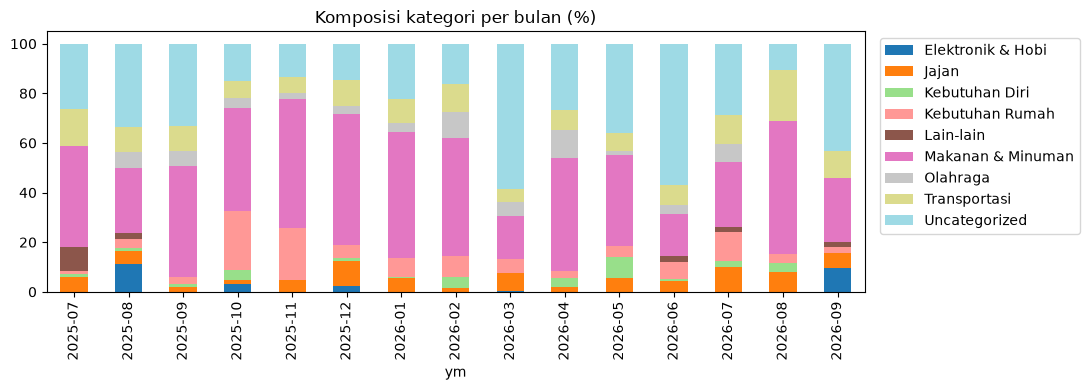

In [4]:
cat = exp.groupby("category").agg(
    frekuensi=("amount", "size"),
    total=("amount", "sum"),
    rata2=("amount", "mean"),
    median=("amount", "median"),
)
cat["porsi_frekuensi_%"] = (cat["frekuensi"] / cat["frekuensi"].sum() * 100).round(1)
cat["porsi_nominal_%"] = (cat["total"] / cat["total"].sum() * 100).round(1)
cat["rank_frekuensi"] = cat["frekuensi"].rank(ascending=False, method="min").astype(int)
cat["rank_nominal"] = cat["total"].rank(ascending=False, method="min").astype(int)
cat = cat.sort_values("total", ascending=False)
display(cat.round(0))

# kategori yang peringkatnya jauh berbeda = sering tapi kecil, atau jarang tapi besar
cat["selisih_rank"] = cat["rank_frekuensi"] - cat["rank_nominal"]
print("Sering tapi kecil (rank frekuensi jauh lebih baik dari rank nominal):",
      list(cat[cat["selisih_rank"] <= -2].index) or "-")
print("Jarang tapi besar (rank nominal jauh lebih baik dari rank frekuensi):",
      list(cat[cat["selisih_rank"] >= 2].index) or "-")

order = cat.index[::-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].barh(order, cat.loc[order, "porsi_nominal_%"], color="#F58518")
axes[0].set_title("Porsi nominal (%)")
axes[1].barh(order, cat.loc[order, "porsi_frekuensi_%"], color="#4C78A8")
axes[1].set_title("Porsi frekuensi (%)")
plt.tight_layout(); plt.show()

# komposisi kategori per bulan (persen)
pivot = exp.pivot_table(index="ym", columns="category", values="amount", aggfunc="sum", fill_value=0)
share = pivot.div(pivot.sum(axis=1), axis=0) * 100
display(share.round(1))
share.index = share.index.astype(str)
share.plot(kind="bar", stacked=True, figsize=(11, 4), colormap="tab20")
plt.title("Komposisi kategori per bulan (%)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

results["kategori"] = cat
results["kategori_per_bulan_persen"] = share

## 4. Item

In [5]:
items = exp.groupby("item").agg(
    frekuensi=("amount", "size"),
    total=("amount", "sum"),
    rata2=("amount", "mean"),
)

print(f"Item paling boros secara akumulasi (top {TOP_N}):")
display(items.sort_values("total", ascending=False).head(TOP_N).round(0))

print(f"Item paling sering dibeli (top {TOP_N}):")
display(items.sort_values("frekuensi", ascending=False).head(TOP_N).round(0))

print(f"Transaksi termahal (top {TOP_N}):")
display(exp.nlargest(TOP_N, "amount")[["date", "item", "category", "amount"]])

# kecil tapi menumpuk: harga per transaksi di bawah median, tapi total besar
small = items[items["rata2"] < exp["amount"].median()].sort_values("total", ascending=False).head(TOP_N)
print("Kecil tapi menumpuk (rata-rata per transaksi di bawah median):")
display(small.round(0))

results["item"] = items.sort_values("total", ascending=False)

Item paling boros secara akumulasi (top 10):


,frekuensi,total,rata2
item,,,
bensin,86,2179500.0,25343.0
lauk,117,1553000.0,13274.0
ayam,53,1001000.0,18887.0
psu,1,799000.0,799000.0
susu,71,658200.0,9270.0
aio cooler,1,655000.0,655000.0
makan,39,605000.0,15513.0
gym,15,602000.0,40133.0
nasgor,29,547000.0,18862.0


Item paling sering dibeli (top 10):


,frekuensi,total,rata2
item,,,
lauk,117,1553000.0,13274.0
bensin,86,2179500.0,25343.0
susu,71,658200.0,9270.0
ayam,53,1001000.0,18887.0
soto,52,525500.0,10106.0
minum,42,411000.0,9786.0
makan,39,605000.0,15513.0
kopi,33,363500.0,11015.0
jajan,33,516500.0,15652.0


Transaksi termahal (top 10):


,date,item,category,amount
1054,2026-06-16,psu,Uncategorized,799000.0
1053,2026-06-16,aio cooler,Uncategorized,655000.0
965,2026-05-18,bayar pajak ganti plat,Uncategorized,435000.0
192,2025-08-30,seat,Uncategorized,371000.0
787,2026-03-04,jam,Uncategorized,356000.0
794,2026-03-05,baju,Uncategorized,350000.0
1274,2026-09-22,surat cek bebas napza,Uncategorized,345000.0
102,2025-07-27,merch,Uncategorized,338000.0
226,2025-09-09,sepatu,Uncategorized,324500.0
1052,2026-06-16,dinamo mesin jahit,Uncategorized,265000.0


Kecil tapi menumpuk (rata-rata per transaksi di bawah median):


,frekuensi,total,rata2
item,,,
susu,71,658200.0,9270.0
soto,52,525500.0,10106.0
minum,42,411000.0,9786.0
kopi,33,363500.0,11015.0
pentol,31,356500.0,11500.0
mie ayam,29,299000.0,10310.0
bakso,16,191000.0,11938.0
bumbu,15,169000.0,11267.0
es,12,94500.0,7875.0


## 5. Pola waktu

,rata2_per_hari,median,jumlah_hari
hari,,,
Senin,51700.0,33000.0,65
Selasa,80052.0,29000.0,66
Rabu,53585.0,34000.0,65
Kamis,58908.0,44000.0,65
Jumat,50908.0,41500.0,65
Sabtu,51716.0,29000.0,65
Minggu,45754.0,26000.0,65


Rata-rata per hari: {'weekday': 'Rp59.095', 'weekend': 'Rp48.735'}


,rata2_per_hari,median,jumlah_hari
fase,,,
tgl 1-10,59823.0,41500.0,150
tgl 11-20,59113.0,31500.0,150
tgl 21-akhir,49744.0,30500.0,156


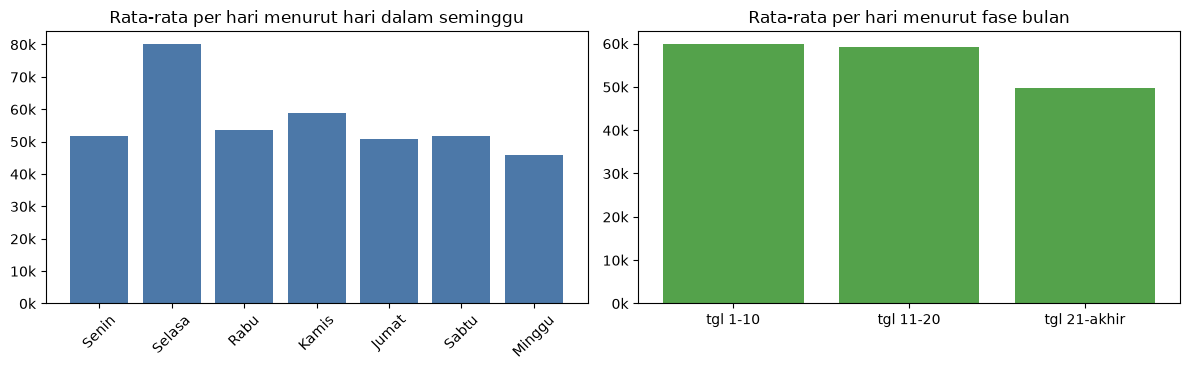

In [6]:
# rata-rata dihitung per HARI (termasuk hari 0), bukan per transaksi
wd = daily.groupby("hari").agg(rata2_per_hari=("total", "mean"),
                               median=("total", "median"),
                               jumlah_hari=("total", "size")).reindex(DAY_NAMES)
display(wd.round(0))

daily["akhir_pekan"] = daily["weekday"] >= 5
we = daily.groupby("akhir_pekan")["total"].mean().rename({False: "weekday", True: "weekend"})
print("Rata-rata per hari:", {k: rp(v) for k, v in we.items()})

daily["fase"] = pd.cut(daily.index.day, bins=[0, 10, 20, 31], labels=["tgl 1-10", "tgl 11-20", "tgl 21-akhir"])
phase = daily.groupby("fase", observed=True)["total"].agg(["mean", "median", "size"]).round(0)
phase.columns = ["rata2_per_hari", "median", "jumlah_hari"]
display(phase)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(wd.index, wd["rata2_per_hari"], color="#4C78A8")
axes[0].yaxis.set_major_formatter(rp_axis); axes[0].set_title("Rata-rata per hari menurut hari dalam seminggu")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(phase.index.astype(str), phase["rata2_per_hari"], color="#54A24B")
axes[1].yaxis.set_major_formatter(rp_axis); axes[1].set_title("Rata-rata per hari menurut fase bulan")
plt.tight_layout(); plt.show()

results["hari_dalam_seminggu"] = wd
results["fase_bulan"] = phase

## 6. Pola perilaku

Streak hari hemat terpanjang: 14 hari (2026-09-02 s.d. 2026-09-15)
Rata-rata pengeluaran sehari SETELAH hari hemat: Rp29.079 vs rata-rata seluruh hari: Rp56.141
Variasi harian (CV): 1.90  (makin kecil makin stabil; > 1 = naik-turun tajam)

5 hari termahal:


,total,isi
date,,
2026-06-16,1772904.0,"minum 7.0k, mie 7.0k, dinamo mesin jahit 265.0..."
2026-05-18,552500.0,"fotocopy berkas 10.0k, bayar pajak ganti plat ..."
2025-07-27,521000.0,"makan 15.0k, bensin 22.0k, minum 3.0k, tiket h..."
2026-09-22,506000.0,"parkir 3.0k, daftar rs umum 20.0k, surat cek b..."
2025-08-30,454500.0,"makan 12.0k, kopi 8.5k, bensin 30.0k, komponen..."


Kombinasi item yang sering muncul di hari yang sama:


,item_a,item_b,jumlah_hari
22,lauk,susu,30
44,bensin,lauk,25
16,soto,susu,15
33,bensin,susu,14
73,nasgor,susu,14
1,bensin,makan,13
64,lauk,mie,12
17,bensin,soto,11
60,ayam,bensin,11
45,kopi,lauk,10


Median harga per kuartal untuk 5 item paling sering:


item,ayam,bensin,lauk,soto,susu
kuartal,,,,,
2025Q3,16000.0,25000.0,10000.0,10000.0,10000.0
2025Q4,17500.0,25000.0,13000.0,9750.0,10000.0
2026Q1,20000.0,27000.0,15000.0,10000.0,10000.0
2026Q2,20000.0,28000.0,14000.0,11000.0,10000.0
2026Q3,15000.0,30000.0,14000.0,10000.0,10000.0


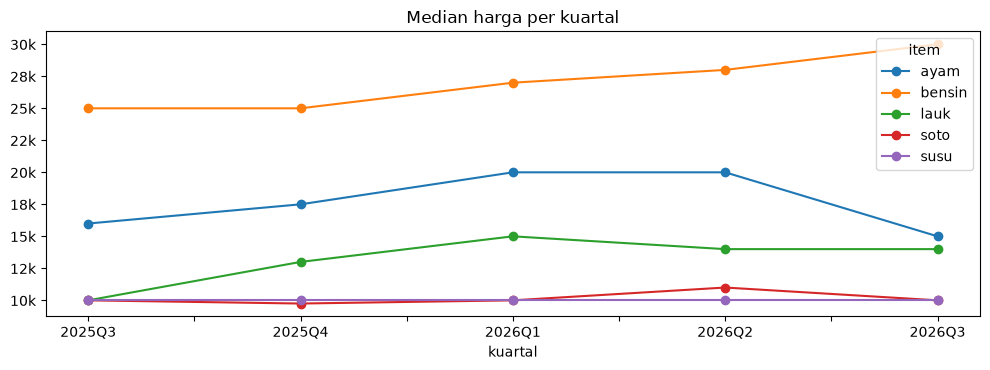

In [7]:
# kalender lengkap: tanggal yang tidak ada di data jadi NaN (bukan 0), sehingga tidak dianggap hari hemat
full = daily["total"].reindex(pd.date_range(daily.index.min(), daily.index.max()))
is_zero = full.eq(0)

# streak hari hemat terpanjang
grp = (~is_zero).cumsum()
streaks = is_zero.groupby(grp).sum()
longest = int(streaks.max()) if len(streaks) else 0
if longest > 0:
    g = streaks.idxmax()
    days = full.index[(grp == g) & is_zero]
    print(f"Streak hari hemat terpanjang: {longest} hari ({days.min().date()} s.d. {days.max().date()})")
else:
    print("Belum ada hari hemat beruntun.")

# apakah hari setelah hari hemat lebih boros?
after_zero = full[full.shift(1).eq(0)].mean()
print(f"Rata-rata pengeluaran sehari SETELAH hari hemat: {rp(after_zero)} "
      f"vs rata-rata seluruh hari: {rp(full.mean())}")

# konsistensi
cv = daily["total"].std() / daily["total"].mean()
print(f"Variasi harian (CV): {cv:.2f}  (makin kecil makin stabil; > 1 = naik-turun tajam)")

# hari termahal + isinya
label = exp["item"] + " " + (exp["amount"] / 1000).round(1).astype(str) + "k"
day_items = label.groupby(exp["date"]).apply(", ".join)
top_days = daily.nlargest(5, "total")[["total"]].copy()
top_days["isi"] = day_items.reindex(top_days.index)
print("\n5 hari termahal:")
display(top_days)

# item yang sering muncul di hari yang sama
by_day = exp.groupby("date")["item"].apply(lambda s: sorted(set(s)))
pairs = Counter(p for its in by_day for p in combinations(its, 2))
pairs_df = pd.DataFrame([(a, b, n) for (a, b), n in pairs.items() if n >= 3],
                        columns=["item_a", "item_b", "jumlah_hari"])
print("Kombinasi item yang sering muncul di hari yang sama:")
display(pairs_df.sort_values("jumlah_hari", ascending=False).head(TOP_N))

# perubahan harga item rutin (median harga per kuartal)
top_items = exp["item"].value_counts().head(5).index
exp["kuartal"] = exp["date"].dt.to_period("Q")
price = (exp[exp["item"].isin(top_items)]
         .pivot_table(index="kuartal", columns="item", values="amount", aggfunc="median"))
print("Median harga per kuartal untuk 5 item paling sering:")
display(price.round(0))
price.index = price.index.astype(str)
price.plot(marker="o", figsize=(10, 3.8), title="Median harga per kuartal")
plt.gca().yaxis.set_major_formatter(rp_axis)
plt.tight_layout(); plt.show()

results["hari_termahal"] = top_days
results["kombinasi_item"] = pairs_df.sort_values("jumlah_hari", ascending=False)
results["harga_per_kuartal"] = price

## 7. Anomali & pengeluaran tak rutin

95 transaksi outlier (kategori dengan >= 10 transaksi):


,date,item,category,amount
1054,2026-06-16,psu,Uncategorized,799000.0
1053,2026-06-16,aio cooler,Uncategorized,655000.0
965,2026-05-18,bayar pajak ganti plat,Uncategorized,435000.0
192,2025-08-30,seat,Uncategorized,371000.0
787,2026-03-04,jam,Uncategorized,356000.0
794,2026-03-05,baju,Uncategorized,350000.0
1274,2026-09-22,surat cek bebas napza,Uncategorized,345000.0
102,2025-07-27,merch,Uncategorized,338000.0
226,2025-09-09,sepatu,Uncategorized,324500.0
1052,2026-06-16,dinamo mesin jahit,Uncategorized,265000.0



Ambang transaksi besar: >= Rp108.000 (26 transaksi = 25.8% dari total nominal)


tipe,besar / tak rutin,harian
ym,,
2025-07,338000.0,1811500.0
2025-08,371000.0,1163000.0
2025-09,484500.0,1184000.0
2025-10,164000.0,1763000.0
2025-11,296000.0,1188000.0
2025-12,135000.0,1853000.0
2026-01,170000.0,1834000.0
2026-02,108000.0,1008000.0
2026-03,963000.0,944000.0


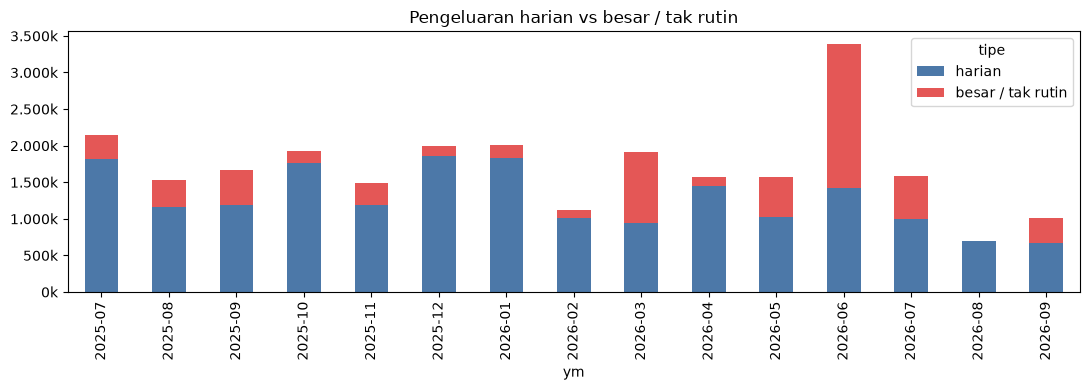

In [8]:
# outlier per kategori (metode IQR): nominal di atas Q3 + 1.5 x IQR
parts = []
for c, g in exp.groupby("category"):
    if len(g) < OUTLIER_MIN_COUNT:
        continue
    q1, q3 = g["amount"].quantile([0.25, 0.75])
    parts.append(g[g["amount"] > q3 + 1.5 * (q3 - q1)])
outliers = pd.concat(parts) if parts else exp.iloc[0:0]
print(f"{len(outliers)} transaksi outlier (kategori dengan >= {OUTLIER_MIN_COUNT} transaksi):")
display(outliers.sort_values("amount", ascending=False)[["date", "item", "category", "amount"]].head(15))

# pisahkan pengeluaran besar / tak rutin agar tren harian terlihat murni
threshold = exp["amount"].quantile(BIG_TICKET_QUANTILE)
exp["tipe"] = np.where(exp["amount"] >= threshold, "besar / tak rutin", "harian")
big_share = exp.loc[exp["tipe"] == "besar / tak rutin", "amount"].sum() / exp["amount"].sum() * 100
print(f"\nAmbang transaksi besar: >= {rp(threshold)} "
      f"({(exp['tipe'] == 'besar / tak rutin').sum()} transaksi = {big_share:.1f}% dari total nominal)")

split = exp.pivot_table(index="ym", columns="tipe", values="amount", aggfunc="sum", fill_value=0)
for col in ["harian", "besar / tak rutin"]:
    if col not in split:
        split[col] = 0
display(split)
split.index = split.index.astype(str)
split[["harian", "besar / tak rutin"]].plot(kind="bar", stacked=True, figsize=(11, 4),
                                            color=["#4C78A8", "#E45756"],
                                            title="Pengeluaran harian vs besar / tak rutin")
plt.gca().yaxis.set_major_formatter(rp_axis)
plt.tight_layout(); plt.show()

results["outlier"] = outliers.sort_values("amount", ascending=False)[["date", "item", "category", "amount"]]
results["harian_vs_besar"] = split

## 8. Kualitas data (supaya insight tidak menyesatkan)

In [9]:
flag = exp["category"].isin(FLAG_CATEGORIES)
print(f"Baris kategori {sorted(FLAG_CATEGORIES)}: {flag.sum()} dari {len(exp)} "
      f"({flag.mean():.1%} frekuensi, {exp.loc[flag, 'amount'].sum() / exp['amount'].sum():.1%} nominal)")
print("\nKategori belum terpetakan (Uncategorized), item terbanyak:")
display(exp.loc[exp["category"] == "Uncategorized", "item"].value_counts().head(TOP_N).to_frame("frekuensi"))

small_amt = exp[exp["amount"] < SMALL_AMOUNT]
print(f"\nNominal < {rp(SMALL_AMOUNT)} (kemungkinan lupa menulis 'k'): {len(small_amt)} baris")
if len(small_amt):
    display(small_amt[["date", "item", "amount", "source_file"]])

# tanggal yang tidak ada sama sekali di data (bukan hari hemat, tapi hari tanpa catatan)
missing = full[full.isna()].index
print(f"\nTanggal tanpa catatan di antara {full.index.min().date()} dan {full.index.max().date()}: {len(missing)}")
if len(missing):
    display(missing.to_period("M").value_counts().sort_index().to_frame("hari_tanpa_catatan"))

print("\nBulan tidak lengkap (jangan dibandingkan langsung dengan bulan penuh):",
      [str(p) for p in monthly.index[~monthly["lengkap"]]] or "-")

dup = exp.duplicated(["date", "item", "amount"], keep=False).sum()
print(f"Baris kembar (tanggal + item + nominal sama): {dup}  (belum tentu salah, mis. bensin dua kali sehari)")

Baris kategori ['Lain-lain', 'Uncategorized']: 155 dari 1220 (12.7% frekuensi, 32.8% nominal)

Kategori belum terpetakan (Uncategorized), item terbanyak:


,frekuensi
item,
tas,2
minun,2
materai,2
masuk pantai,1
km mandi,1
kamar mandi,1
iuran gas,1
parking,1
eating,1



Nominal < Rp1.000 (kemungkinan lupa menulis 'k'): 0 baris

Tanggal tanpa catatan di antara 2025-07-01 dan 2026-09-29: 0

Bulan tidak lengkap (jangan dibandingkan langsung dengan bulan penuh): ['2026-09']
Baris kembar (tanggal + item + nominal sama): 6  (belum tentu salah, mis. bensin dua kali sehari)


## 9. Ringkasan otomatis

In [10]:
full_months = monthly[monthly["lengkap"]] if monthly["lengkap"].any() else monthly
top_cat_nom = cat["porsi_nominal_%"].idxmax()
top_cat_freq = cat["frekuensi"].idxmax()
best_wd = wd["rata2_per_hari"].idxmax()
low_wd = wd["rata2_per_hari"].idxmin()
top_item = items["total"].idxmax()

lines = [
    f"Total {rp(exp['amount'].sum())} selama {n_days} hari ({len(monthly)} bulan); "
    f"rata-rata {rp(daily['total'].mean())}/hari, median {rp(daily['total'].median())}/hari.",
    f"Kategori terbesar berdasarkan nominal: {top_cat_nom} ({cat.loc[top_cat_nom, 'porsi_nominal_%']:.1f}%). "
    f"Paling sering: {top_cat_freq} ({cat.loc[top_cat_freq, 'porsi_frekuensi_%']:.1f}% transaksi).",
    f"Item paling boros secara akumulasi: {top_item} ({rp(items.loc[top_item, 'total'])}, "
    f"{int(items.loc[top_item, 'frekuensi'])}x).",
    f"Bulan (lengkap) termahal: {full_months['total'].idxmax()} ({rp(full_months['total'].max())}); "
    f"termurah: {full_months['total'].idxmin()} ({rp(full_months['total'].min())}).",
    f"Hari paling boros: {best_wd} ({rp(wd.loc[best_wd, 'rata2_per_hari'])}/hari); paling hemat: {low_wd}.",
    f"Weekend vs weekday: {rp(we['weekend'])} vs {rp(we['weekday'])} per hari.",
    f"Hari tanpa pengeluaran: {zero_days} ({zero_days / n_days:.1%}); streak terpanjang {longest} hari.",
    f"Transaksi besar / tak rutin (>= {rp(threshold)}) menyumbang {big_share:.1f}% dari total nominal.",
    f"Data belum bersih sepenuhnya: {flag.mean():.1%} transaksi masih Uncategorized / Lain-lain.",
]
print("RINGKASAN")
for l in lines:
    print(" -", l)

RINGKASAN
 - Total Rp25.600.464 selama 456 hari (15 bulan); rata-rata Rp56.141/hari, median Rp34.000/hari.
 - Kategori terbesar berdasarkan nominal: Makanan & Minuman (36.9%). Paling sering: Makanan & Minuman (57.2% transaksi).
 - Item paling boros secara akumulasi: bensin (Rp2.179.500, 86x).
 - Bulan (lengkap) termahal: 2026-06 (Rp3.390.964); termurah: 2026-08 (Rp688.500).
 - Hari paling boros: Selasa (Rp80.052/hari); paling hemat: Minggu.
 - Weekend vs weekday: Rp48.735 vs Rp59.095 per hari.
 - Hari tanpa pengeluaran: 77 (16.9%); streak terpanjang 14 hari.
 - Transaksi besar / tak rutin (>= Rp108.000) menyumbang 25.8% dari total nominal.
 - Data belum bersih sepenuhnya: 12.7% transaksi masih Uncategorized / Lain-lain.


## 10. Simpan hasil (opsional)

In [11]:
if SAVE_OUTPUT:
    OUTPUT_DIR.mkdir(exist_ok=True)
    for name, table in results.items():
        table.to_csv(OUTPUT_DIR / f"{name}.csv", encoding="utf-8")
    print(f"{len(results)} tabel tersimpan di {OUTPUT_DIR}")
else:
    print("SAVE_OUTPUT = False, tidak ada yang disimpan. Ubah di bagian konfigurasi jika ingin menyimpan.")

SAVE_OUTPUT = False, tidak ada yang disimpan. Ubah di bagian konfigurasi jika ingin menyimpan.
